# B6 — Préparation des données images (MVTec AD, catégorie `hazelnut`)

Ce notebook prépare les images pour un auto-encodeur de détection d'anomalies (approche non supervisée : on apprend à reconstruire uniquement des pièces **saines**, et tout ce qui est mal reconstruit devient suspect).

## Étape 1 — Redimensionnement des images

Les images MVTec d'origine (`artifacts/hazelnut`) sont en haute résolution (1024×1024). On les redimensionne toutes en **256×256** et on les sauvegarde dans `artifacts/hazelnut_resized`, en conservant la structure d'origine :

- `train/good` — pièces saines pour l'entraînement,
- `test/good` — pièces saines pour l'évaluation,
- `test/<défaut>` — pièces défectueuses (crack, cut, hole, print).

On utilise l'interpolation `INTER_AREA`, adaptée à la réduction de taille, et on garde le format BGR d'OpenCV (aucune conversion de couleur nécessaire pour un simple redimensionnement disque-à-disque).

In [ ]:
from pathlib import Path

import cv2

DATA_DIR = Path("artifacts/hazelnut")
RESIZED_DIR = Path("artifacts/hazelnut_resized")
IMG_SIZE = (256, 256)  # (largeur, hauteur)


def resize_folder_to_disk(src_dir, dst_dir, size=IMG_SIZE):
    """Redimensionne les images .png de src_dir (couleur) et les écrit dans dst_dir."""
    dst_dir.mkdir(parents=True, exist_ok=True)
    paths = sorted(Path(src_dir).glob("*.png"))
    for path in paths:
        img = cv2.imread(str(path))  # BGR (format natif OpenCV, réutilisé tel quel pour imwrite)
        img = cv2.resize(img, size, interpolation=cv2.INTER_AREA)  # INTER_AREA = réduction de taille
        cv2.imwrite(str(dst_dir / path.name), img)
    return len(paths)


def resize_masks_to_disk(src_dir, dst_dir, size=IMG_SIZE):
    """Redimensionne les masques binaires .png (grayscale) avec INTER_NEAREST (préserve le 0/255)."""
    dst_dir.mkdir(parents=True, exist_ok=True)
    paths = sorted(Path(src_dir).glob("*.png"))
    for path in paths:
        mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, size, interpolation=cv2.INTER_NEAREST)  # garde le masque binaire
        cv2.imwrite(str(dst_dir / path.name), mask)
    return len(paths)


total = 0

# Images (couleur) : train/ et test/
for split in ["train", "test"]:
    for sub in sorted(p for p in (DATA_DIR / split).iterdir() if p.is_dir()):
        n = resize_folder_to_disk(sub, RESIZED_DIR / split / sub.name)
        total += n
        print(f"{split}/{sub.name:<6}: {n} images -> {RESIZED_DIR / split / sub.name}")

# Masques binaires : ground_truth/<défaut>
for sub in sorted(p for p in (DATA_DIR / "ground_truth").iterdir() if p.is_dir()):
    n = resize_masks_to_disk(sub, RESIZED_DIR / "ground_truth" / sub.name)
    total += n
    print(f"ground_truth/{sub.name:<6}: {n} masques -> {RESIZED_DIR / 'ground_truth' / sub.name}")

print(f"\nTotal : {total} fichiers redimensionnés en {IMG_SIZE[0]}×{IMG_SIZE[1]} dans {RESIZED_DIR}")

In [ ]:
n_resized = len(list(RESIZED_DIR.rglob("*.png")))
print(f"{n_resized} images redimensionnées et sauvegardées dans {RESIZED_DIR}")

## Étape 2 — Normalisation des images

On normalise les pixels de **[0, 255]** vers **[0, 1]** (division par 255), ce qui stabilise l'entraînement de l'auto-encodeur et met les images d'entrée dans le même intervalle que la sortie sigmoïde du décodeur.

Comme la normalisation produit des valeurs **flottantes**, on ne peut pas les stocker en PNG (format entier) : on sauvegarde donc chaque image en **`.npy`** (tableau NumPy `float32` en RGB) dans `artifacts/hazelnut_normalised`, en conservant la structure des dossiers.

In [ ]:
import numpy as np

NORMALISED_DIR = Path("artifacts/hazelnut_normalised")


def normalise_folder_to_disk(src_dir, dst_dir):
    """Charge les .png de src_dir, normalise en [0, 1] (RGB float32) et sauvegarde en .npy."""
    dst_dir.mkdir(parents=True, exist_ok=True)
    paths = sorted(Path(src_dir).glob("*.png"))
    for path in paths:
        img = cv2.imread(str(path))                       # BGR uint8
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)        # -> RGB
        img = img.astype("float32") / 255.0               # [0, 255] -> [0, 1]
        np.save(dst_dir / f"{path.stem}.npy", img)
    return len(paths)


def normalise_masks_to_disk(src_dir, dst_dir):
    """Charge les masques .png (grayscale), binarise en {0, 1} (float32) et sauvegarde en .npy."""
    dst_dir.mkdir(parents=True, exist_ok=True)
    paths = sorted(Path(src_dir).glob("*.png"))
    for path in paths:
        mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)  # 1 canal, 0/255
        mask = (mask > 127).astype("float32")              # -> {0.0, 1.0}
        np.save(dst_dir / f"{path.stem}.npy", mask)
    return len(paths)


total = 0

# Images (couleur) : train/ et test/
for split in ["train", "test"]:
    for sub in sorted(p for p in (RESIZED_DIR / split).iterdir() if p.is_dir()):
        n = normalise_folder_to_disk(sub, NORMALISED_DIR / split / sub.name)
        total += n
        print(f"{split}/{sub.name:<6}: {n} images -> {NORMALISED_DIR / split / sub.name}")

# Masques binaires : ground_truth/<défaut>
for sub in sorted(p for p in (RESIZED_DIR / "ground_truth").iterdir() if p.is_dir()):
    n = normalise_masks_to_disk(sub, NORMALISED_DIR / "ground_truth" / sub.name)
    total += n
    print(f"ground_truth/{sub.name:<6}: {n} masques -> {NORMALISED_DIR / 'ground_truth' / sub.name}")

print(f"\nTotal : {total} fichiers normalisés (float32) dans {NORMALISED_DIR}")

## Étape 3 — Split train / validation / test (70 / 15 / 15)

L'auto-encodeur s'entraîne **uniquement sur des images saines** : on part des images `good` d'entraînement normalisées (`train/good`), on les **mélange** (shuffle avec graine fixe pour la reproductibilité), puis on les répartit en **70 % train / 15 % validation / 15 % test**.

- `X_train` — entraînement de l'auto-encodeur,
- `X_val` — calibration du seuil de détection (partie 2),
- `X_test` — évaluation sur des saines (les images **défectueuses**, chargées séparément, constitueront les anomalies à détecter).

In [10]:
def load_npy_folder(folder):
    """Charge toutes les images .npy d'un dossier en un tableau (N, 256, 256, 3)."""
    paths = sorted(Path(folder).glob("*.npy"))
    return np.stack([np.load(p) for p in paths])


# Images saines d'entraînement normalisées (train/good uniquement)
good = load_npy_folder(NORMALISED_DIR / "train" / "good")

# Shuffle reproductible
rng = np.random.default_rng(42)
good = good[rng.permutation(len(good))]

# Split 70 / 15 / 15
n = len(good)
n_train = int(0.70 * n)
n_val = int(0.15 * n)

X_train = good[:n_train]
X_val = good[n_train:n_train + n_val]
X_test = good[n_train + n_val:]

print(f"total train/good : {n}")
print(f"X_train : {X_train.shape} ({len(X_train) / n:.0%})")
print(f"X_val   : {X_val.shape} ({len(X_val) / n:.0%})")
print(f"X_test  : {X_test.shape} ({len(X_test) / n:.0%})")

total train/good : 391
X_train : (273, 256, 256, 3) (70%)
X_val   : (58, 256, 256, 3) (15%)
X_test  : (60, 256, 256, 3) (15%)


## Vérification visuelle : une image saine vs une défectueuse

On affiche une image saine (`train/good`) et une image défectueuse (`test/crack`) redimensionnées, pour vérifier le chargement et comparer visuellement une pièce normale et une pièce avec fissure.

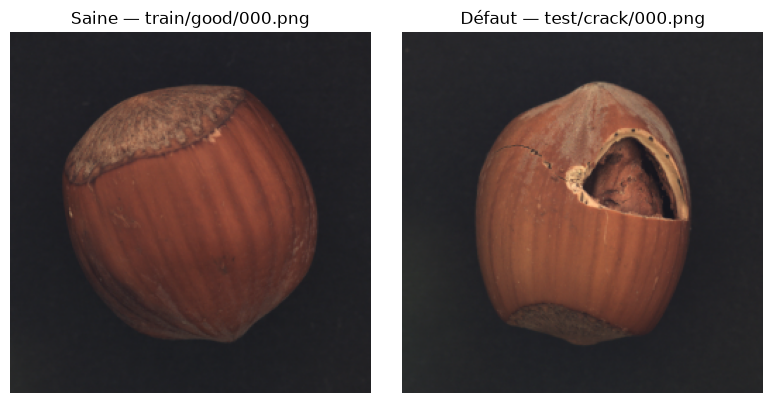

In [11]:
import matplotlib.pyplot as plt

good_path = sorted((RESIZED_DIR / "train" / "good").glob("*.png"))[0]
crack_path = sorted((RESIZED_DIR / "test" / "crack").glob("*.png"))[0]

# Lecture BGR -> RGB pour affichage correct avec matplotlib
good_img = cv2.cvtColor(cv2.imread(str(good_path)), cv2.COLOR_BGR2RGB)
crack_img = cv2.cvtColor(cv2.imread(str(crack_path)), cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(good_img)
axes[0].set_title(f"Saine — train/good/{good_path.name}")
axes[1].imshow(crack_img)
axes[1].set_title(f"Défaut — test/crack/{crack_path.name}")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Étape 4 — Pipeline d'augmentation (Albumentations)

On construit un pipeline d'augmentation appliqué **uniquement aux saines d'entraînement** (`X_train`), pour agrandir artificiellement le jeu d'entraînement de l'auto-encodeur :

- **flips** horizontal et vertical,
- **rotations légères** (±15°),
- **translation / échelle** (±5 %, zoom 0.9–1.1) via `Affine`,
- **variations d'éclairage** (luminosité / contraste ±20 %).

🔎 **Point de réflexion** : la noisette est un objet **centré mais non aligné en rotation** (contrairement à `bottle`), donc flips et rotations sont ici pertinents — ils reflètent des orientations réalistes de la pièce. En revanche, une augmentation géométrique **trop forte** élargirait la notion de « normal » et rendrait l'auto-encodeur plus tolérant aux défauts (il apprendrait à bien reconstruire des variations excessives). On garde donc des transformations **modérées**, et pas de déformation qui altérerait la texture (celle-là même qui trahit les défauts).

In [12]:
import albumentations as A

augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Affine(
        scale=(0.9, 1.1),                 # zoom léger
        translate_percent=(-0.05, 0.05),  # translation ±5 %
        rotate=(-15, 15),                 # rotation légère ±15°
        p=0.7,
    ),
    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.5,
    ),
])


def augment_image(img):
    """Applique le pipeline d'augmentation à une image (renvoie une version augmentée)."""
    return augment(image=img)["image"]


# Exemple : une image augmentée à partir de la première saine d'entraînement
example_aug = augment_image(X_train[0])
print("pipeline d'augmentation prêt")
print(f"image d'origine : {X_train[0].shape} {X_train[0].dtype}")
print(f"image augmentée : {example_aug.shape} {example_aug.dtype}")

pipeline d'augmentation prêt
image d'origine : (256, 256, 3) float32
image augmentée : (256, 256, 3) float32


## Visualisation : original vs versions augmentées

On applique plusieurs fois le pipeline (aléatoire) à **une même image saine** pour visualiser la diversité générée : l'originale, puis 5 versions augmentées. Chaque exécution donne des variantes différentes (flips, rotations, décalages, éclairage).

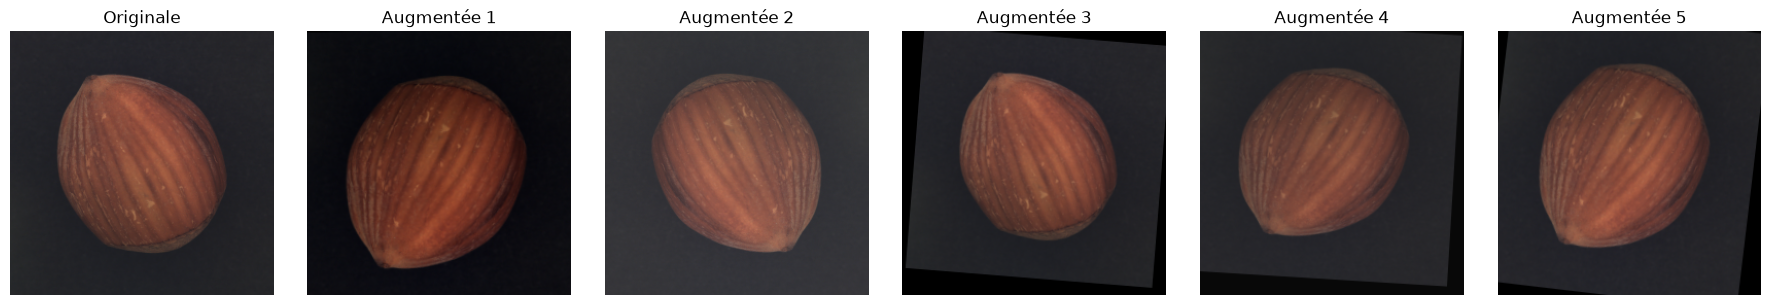

In [13]:
original = X_train[0]
n_aug = 5

fig, axes = plt.subplots(1, n_aug + 1, figsize=(3 * (n_aug + 1), 3))

axes[0].imshow(original)
axes[0].set_title("Originale")
axes[0].axis("off")

for i in range(1, n_aug + 1):
    axes[i].imshow(augment_image(original))
    axes[i].set_title(f"Augmentée {i}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()